In [8]:
import pandas as pd
fba_df = pd.read_csv("fba_results.csv")
graph_df = pd.read_csv("graph_data_with_complexity.csv")

In [10]:
full_df = pd.merge(graph_df, fba_df, on='sample')

In [12]:
full_df

,sample,nodes,edges,avg_degree,global_clustering,avg_local_clustering,largest_connected_component,condition_x,diffusion_efficiency,modularity,assortativity,hierarchical_complexity,condition_y,status,objective_value,total_abs_flux,active_reactions
0,TCGA_Tumor_A3A3,6496,64794,19.95,0.2261,0.6576,6482,Tumor,0.3447,0.712022,-0.132966,0.051354,Tumor,optimal,124.859749,151577.453199,849
1,TCGA_Tumor_A3RK,6518,65317,20.04,0.2231,0.6584,6504,Tumor,0.3451,0.711624,-0.133225,0.055589,Tumor,optimal,124.868148,158244.609113,945
2,TCGA_Tumor_A3KG,6480,64995,20.06,0.2257,0.6605,6466,Tumor,0.3450,0.708071,-0.133176,0.051049,Tumor,optimal,124.868148,107372.483261,1002
3,TCGA_Tumor_AAU7,6578,65735,19.99,0.2210,0.6588,6559,Tumor,0.3440,0.712486,-0.133236,0.052163,Tumor,optimal,124.867964,129567.000109,1295
4,TCGA_Tumor_A9VH,6535,65276,19.98,0.2228,0.6580,6516,Tumor,0.3438,0.712658,-0.133594,0.050500,Tumor,optimal,124.868148,165189.256758,1216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,TCGA_Tumor_A5MZ,6532,65397,20.02,0.2221,0.6593,6513,Tumor,0.3443,0.712784,-0.133562,0.051237,Tumor,optimal,124.868148,131739.702932,651
419,TCGA_Tumor_AACD,6467,64771,20.03,0.2286,0.6581,6450,Tumor,0.3438,0.709579,-0.133297,0.046075,Tumor,optimal,124.868148,153346.125009,785
420,TCGA_Healthy_A1EG,6462,64684,20.02,0.2284,0.6568,6446,Healthy,0.3440,0.720046,-0.133286,0.051725,Healthy,optimal,124.868148,161802.762754,1026
421,TCGA_Tumor_A73D,6426,64661,20.12,0.2277,0.6605,6407,Tumor,0.3448,0.709090,-0.134257,0.047778,Tumor,optimal,124.868148,133986.302901,1005


In [14]:
full_df = full_df.drop(columns=['status', 'condition_y'])
full_df.describe()

,nodes,edges,avg_degree,global_clustering,avg_local_clustering,largest_connected_component,diffusion_efficiency,modularity,assortativity,hierarchical_complexity,objective_value,total_abs_flux,active_reactions
count,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000
mean,6471.600473,64859.652482,20.044870,0.226657,0.659430,6455.676123,0.344513,0.712278,-0.133426,0.050730,124.867556,145820.019453,1041.380615
std,64.220397,540.688857,0.107863,0.005664,0.002148,64.514421,0.000782,0.004479,0.001067,0.002211,0.002103,19196.098706,193.071284
min,5983.000000,61379.000000,19.450000,0.214900,0.652200,5975.000000,0.340900,0.702561,-0.138847,0.045100,124.859472,106027.745771,624.000000
25%,6443.000000,64649.500000,20.005000,0.223500,0.658050,6428.000000,0.344100,0.708977,-0.133854,0.049187,124.868148,131647.831181,930.000000
50%,6479.000000,64917.000000,20.040000,0.225700,0.659600,6461.000000,0.344600,0.712025,-0.133530,0.050613,124.868148,143560.542239,1047.000000
75%,6515.000000,65230.500000,20.090000,0.227800,0.660700,6498.500000,0.345000,0.714269,-0.133132,0.052177,124.868148,156081.588004,1164.500000
max,6578.000000,65735.000000,20.630000,0.279500,0.670800,6559.000000,0.346300,0.729270,-0.127398,0.059348,124.868148,230267.634106,1605.000000


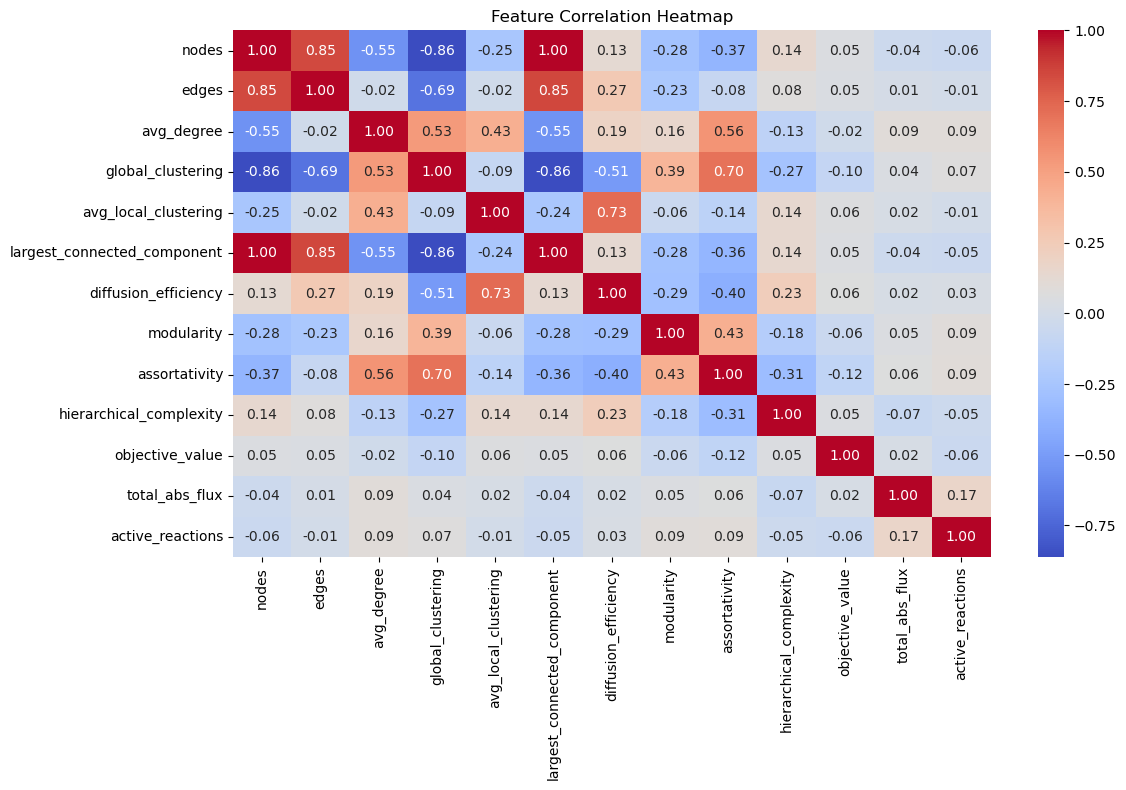

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(full_df.drop(columns=['sample', 'condition_x']).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

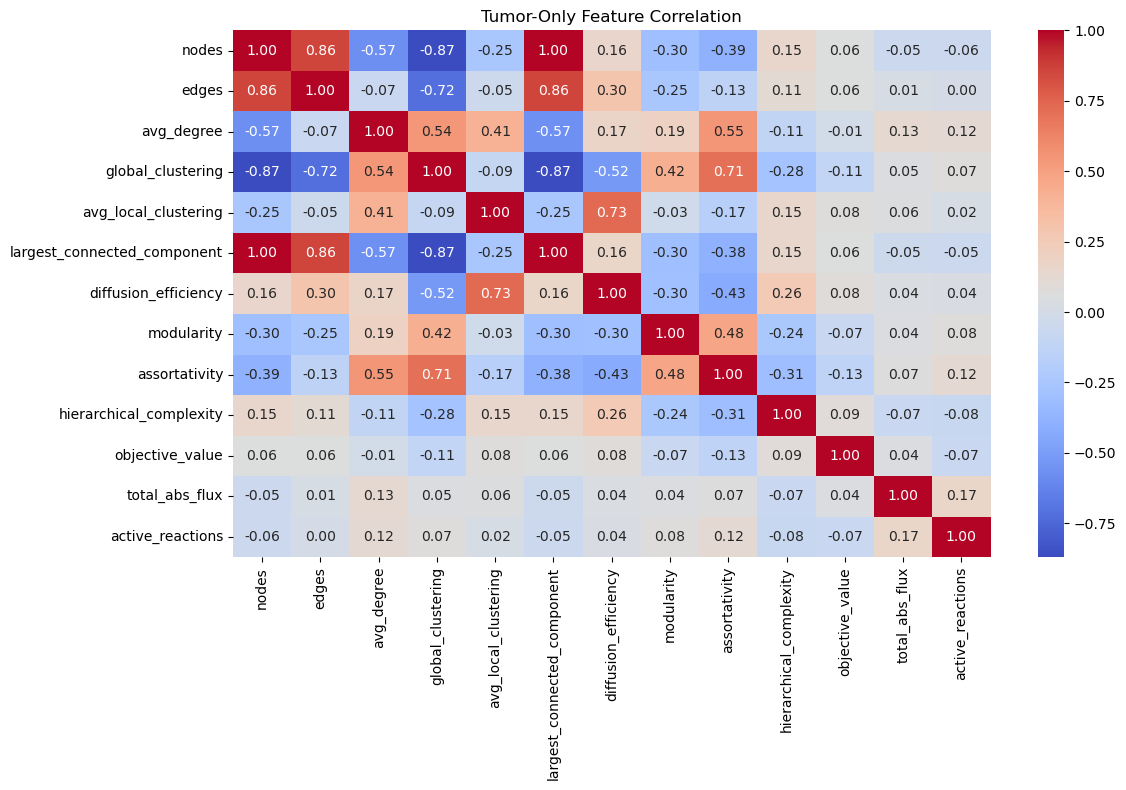

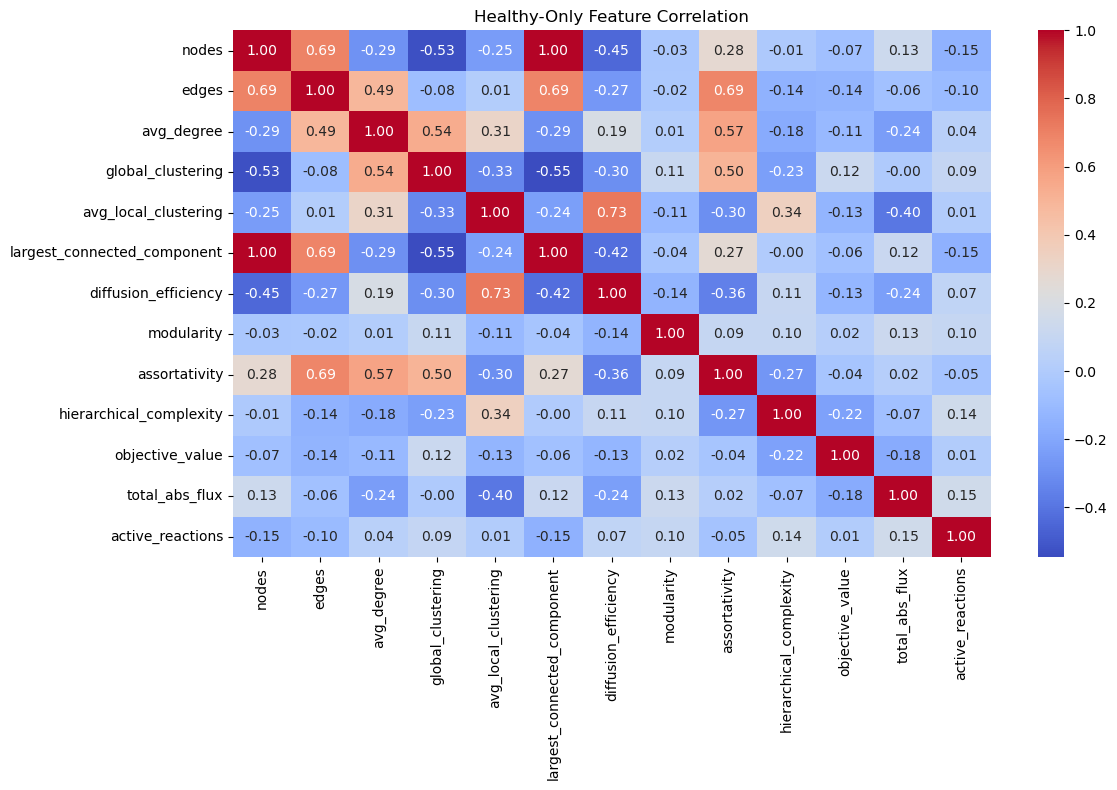

In [17]:
# Split data
tumor_df = full_df[full_df['condition_x'] == 'Tumor']
healthy_df = full_df[full_df['condition_x'] == 'Healthy']

# Correlation heatmap for tumor
plt.figure(figsize=(12, 8))
sns.heatmap(tumor_df.drop(columns=['sample', 'condition_x']).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Tumor-Only Feature Correlation")
plt.tight_layout()
plt.show()

# Correlation heatmap for healthy
plt.figure(figsize=(12, 8))
sns.heatmap(healthy_df.drop(columns=['sample', 'condition_x']).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Healthy-Only Feature Correlation")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

# Define features and label
X = full_df[[
    'edges',
    'avg_degree',
    'global_clustering',
    'diffusion_efficiency',
    'objective_value',
    'total_abs_flux',
    'active_reactions',
    "modularity",
    "assortativity",
    "hierarchical_complexity"
]]

# Convert 'Tumor' / 'Healthy' into binary label
y = full_df['condition_x'].map({'Healthy': 0, 'Tumor': 1})

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [20]:
# Random forest 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[  2  13]
 [  0 112]]
              precision    recall  f1-score   support

           0       1.00      0.13      0.24        15
           1       0.90      1.00      0.95       112

    accuracy                           0.90       127
   macro avg       0.95      0.57      0.59       127
weighted avg       0.91      0.90      0.86       127



In [23]:
# Logistic regression 
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[12  3]
 [35 77]]
              precision    recall  f1-score   support

           0       0.26      0.80      0.39        15
           1       0.96      0.69      0.80       112

    accuracy                           0.70       127
   macro avg       0.61      0.74      0.59       127
weighted avg       0.88      0.70      0.75       127



### SMOTE for Synthetic Minority Oversampling Technique

In [27]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Check new balance
print(y_train_bal.value_counts())

condition_x
1    261
0    261
Name: count, dtype: int64


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [29]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_bal, y_train_bal)
y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[  5  10]
 [ 11 101]]
              precision    recall  f1-score   support

           0       0.31      0.33      0.32        15
           1       0.91      0.90      0.91       112

    accuracy                           0.83       127
   macro avg       0.61      0.62      0.61       127
weighted avg       0.84      0.83      0.84       127



In [31]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_bal, y_train_bal)
y_pred = xgb.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[  6   9]
 [ 10 102]]
              precision    recall  f1-score   support

           0       0.38      0.40      0.39        15
           1       0.92      0.91      0.91       112

    accuracy                           0.85       127
   macro avg       0.65      0.66      0.65       127
weighted avg       0.85      0.85      0.85       127



/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [08:15:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### ROC couve and AUC

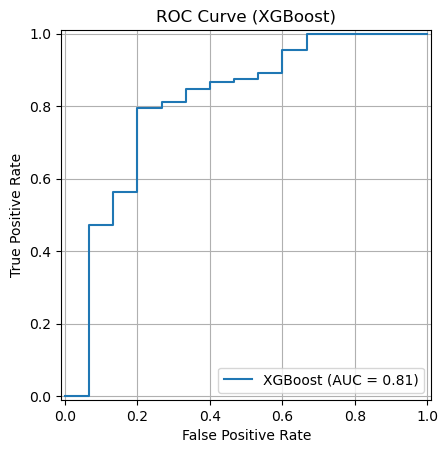

In [34]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Get predicted probabilities
y_proba = xgb.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='XGBoost').plot()
plt.title("ROC Curve (XGBoost)")
plt.grid(True)
plt.show()

### Hyperparameters grid search 

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

grid_search = GridSearchCV(xgb, param_grid, scoring='f1_macro', cv=5, n_jobs=-1)
grid_search.fit(X_train_bal, y_train_bal)

print("Best Parameters:", grid_search.best_params_)

# Retrain with best parameters
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}
[[  6   9]
 [ 10 102]]
              precision    recall  f1-score   support

           0       0.38      0.40      0.39        15
           1       0.92      0.91      0.91       112

    accuracy                           0.85       127
   macro avg       0.65      0.66      0.65       127
weighted avg       0.85      0.85      0.85       127



### Feature Importance 

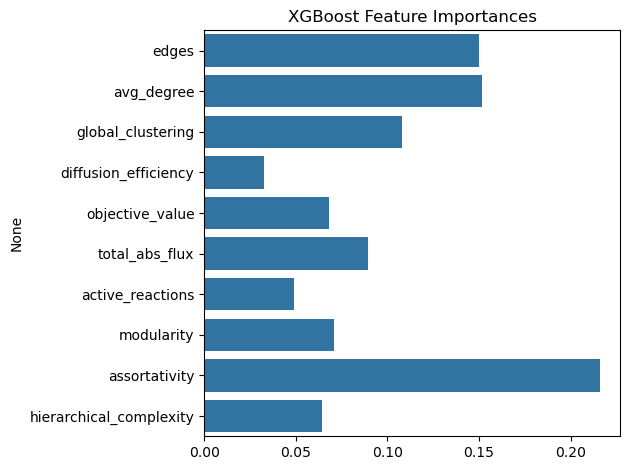

In [42]:
importances = best_xgb.feature_importances_
feature_names = X_train.columns

# Plot
sns.barplot(x=importances, y=feature_names)
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()